In [5]:
pip install pandas openpyxl


Note: you may need to restart the kernel to use updated packages.


openpyxl, pandas'ın .xlsx dosyalarını okuyabilmesi için arka planda kullandığı motordur.

# Dosya Okuma

In [29]:
import pandas as pd

df = pd.read_excel("yorum_Veri.xlsx")

# Belirli bir sheet okumak istersen
# df = pd.read_excel("dosya.xlsx", sheet_name="Sayfa1")

# İlk birkaç satırı gör
df.head()


,SIRA_NO,URUN_NO,LINK_AD,SPOR_DALI,MARKA,FIYAT,TUM_YILDIZ,TUM_YORUM,YORUM_YILDIZ,YORUM_KULLANIM_SURESI,YORUM,YORUMUN_POLARITESI
0,1,1,https://www.decathlon.com.tr/r/yetiskin-binici...,at_binicilik,Fouganza,1190,4.7,12,5,Kullanılan süre 2 ile 8 hafta arası tarihinden...,"Görünüm ve tasarım başarısıyla, rahatlık ve şı...",NaN
1,2,1,https://www.decathlon.com.tr/r/yetiskin-binici...,at_binicilik,Fouganza,1190,4.7,12,5,Kullanılan süre 1 hafta ya da daha az tarihind...,Ürün elime Aras kargo sebebiyle ulaşmadı. Karg...,NaN
2,3,1,https://www.decathlon.com.tr/r/yetiskin-binici...,at_binicilik,Fouganza,1190,4.7,12,5,Kullanılan süre 1 hafta ya da daha az tarihind...,Ürün gerçekten fiyatına göre iyi. Eğer ayağını...,NaN
3,4,1,https://www.decathlon.com.tr/r/yetiskin-binici...,at_binicilik,Fouganza,1190,4.7,12,5,Kullanılan süre 2 ile 8 hafta arası tarihinden...,Ürün çok kaliteli tam kalıp işimi gördü baya a...,NaN
4,5,1,https://www.decathlon.com.tr/r/yetiskin-binici...,at_binicilik,Fouganza,1190,4.7,12,5,Kullanılan süre 2 ile 8 hafta arası tarihinden...,Çizme çok güzel binicilik için tam olması gere...,NaN


In [30]:
# Sütun isimlerini gör
df.columns

Index(['SIRA_NO', 'URUN_NO', 'LINK_AD', 'SPOR_DALI', 'MARKA', 'FIYAT',
       'TUM_YILDIZ', 'TUM_YORUM', 'YORUM_YILDIZ', 'YORUM_KULLANIM_SURESI',
       'YORUM', 'YORUMUN_POLARITESI'],
      dtype='object')

# Duplicate Kontrolü

In [31]:
# Tüm satır bazında duplicate
print(f"Duplicate satır sayısı: {df.duplicated().sum()}")

# Sadece YORUM sütununa göre duplicate (aynı yorum birden fazla kez girilmiş mi)
print(f"Aynı yorum tekrarı: {df.duplicated(subset=['YORUM']).sum()}")

# Duplicate satırları göster
df[df.duplicated(subset=["YORUM"], keep=False)].sort_values("YORUM")


Duplicate satır sayısı: 0
Aynı yorum tekrarı: 1368


,SIRA_NO,URUN_NO,LINK_AD,SPOR_DALI,MARKA,FIYAT,TUM_YILDIZ,TUM_YORUM,YORUM_YILDIZ,YORUM_KULLANIM_SURESI,YORUM,YORUMUN_POLARITESI
10218,10219,1,https://www.decathlon.com.tr/r/cocuk-gri-beyaz...,tenis,Decathlon,680,4.7,115,5,Kullanılan süre 3 ile 6 ay arası tarihinden beri,"""Çocuğuma ayakkabı alıyorum hemen yırtılıyor d...",NaN
6307,6308,7,https://www.decathlon.com.tr/r/cocuk-cirt-cirt...,outdoor_sporlar,Quechua,980,4.7,75,5,Kullanılan süre 3 ile 6 ay arası tarihinden beri,"""Çocuğuma ayakkabı alıyorum hemen yırtılıyor d...",NaN
9096,9097,39,https://www.decathlon.com.tr/r/erkek-outdoor-k...,outdoor_sporlar,Quechua,2750,4.8,400,5,Kullanılan süre 1 yıldan daha fazla tarihinden...,.,NaN
4207,4208,7,https://www.decathlon.com.tr/r/erkek-kosu-ayak...,kosu,Kiprun,1790,4.6,356,4,Kullanılan süre 1 hafta ya da daha az tarihind...,.,NaN
6081,6082,5,https://www.decathlon.com.tr/r/kadin-outdoor-k...,outdoor_sporlar,Quechua,2750,4.8,379,5,Kullanılan süre 1 hafta ya da daha az tarihind...,.,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8482,8483,35,https://www.decathlon.com.tr/r/kadin-su-gecirm...,outdoor_sporlar,Quechua,1250,4.6,67,5,Kullanılan süre 2 ile 8 hafta arası tarihinden...,👍,NaN
5549,5550,3,https://www.decathlon.com.tr/r/erkek-outdoor-k...,outdoor_sporlar,Quechua,2050,4.8,81,5,Kullanılan süre 2 ile 8 hafta arası tarihinden...,👍👍,NaN
4754,4755,11,https://www.decathlon.com.tr/r/erkek-arazi-tip...,kosu,Kiprun,2990,4.6,122,5,Kullanılan süre 2 ile 8 hafta arası tarihinden...,👍👍,NaN
11076,11077,2,https://www.decathlon.com.tr/r/cocuk-paten-mav...,paten,Oxelo,2290,4.8,330,5,Kullanılan süre 3 ile 6 ay arası tarihinden beri,👍👍👍,NaN


Veri ön işleme aşamasında yinelenen yorum metinleri incelenmiş; ancak bu tekrarların farklı kullanıcılara ait bağımsız değerlendirmeler olduğu görülmüştür. Söz konusu yorumlar silinmemiş, zira aynı ifadenin birden fazla kullanıcı tarafından kullanılması o duygu yöneliminin yaygınlığını temsil etmekte olup bilgi taşımaktadır.

# YILDIZ & PUAN - KULLANIM SURESI

In [32]:
print("=== YORUM_YILDIZ ===")
print(df["YORUM_YILDIZ"].value_counts().sort_index())
print(f"\nMin: {df['YORUM_YILDIZ'].min()} | Max: {df['YORUM_YILDIZ'].max()}")

print("\n=== YORUM_KULLANIM_SURESI ===")
print(df["YORUM_KULLANIM_SURESI"].value_counts())


=== YORUM_YILDIZ ===
YORUM_YILDIZ
1      280
2      145
3      388
4     1315
5    10369
Name: count, dtype: int64

Min: 1 | Max: 5

=== YORUM_KULLANIM_SURESI ===
YORUM_KULLANIM_SURESI
Kullanılan süre 2 ile 8 hafta arası tarihinden beri      6114
Kullanılan süre 1 hafta ya da daha az tarihinden beri    2384
Kullanılan süre 3 ile 6 ay arası tarihinden beri         2107
Kullanılan süre 1 yıldan daha fazla tarihinden beri       681
Kullanılan süre 7 ile 12 ay arası tarihinden beri         594
Kullanılan süre 2 yıldan daha fazla tarihinden beri       515
Name: count, dtype: int64


- Kullanım süresi değişkeni, kategoriler arasında hiyerarşik bir ilişki barındırdığından ordinal ölçek düzeyinde ele alınmış ve 1'den 6'ya sıralı sayısal kodlara dönüştürülmüştür. Bu dönüşüm, değişkenin istatistiksel analizlerde ve model eğitiminde doğru biçimde temsil edilmesini sağlamaktadır.

-  ordinal encoding (sıralı kodlama) 

In [33]:
# 1. Adım — map 
kullanim_suresi_map = {
    "Kullanılan süre 1 hafta ya da daha az tarihinden beri" : 1,
    "Kullanılan süre 2 ile 8 hafta arası tarihinden beri"   : 2,
    "Kullanılan süre 3 ile 6 ay arası tarihinden beri"      : 3,
    "Kullanılan süre 7 ile 12 ay arası tarihinden beri"     : 4,
    "Kullanılan süre 1 yıldan daha fazla tarihinden beri"   : 5,
    "Kullanılan süre 2 yıldan daha fazla tarihinden beri"   : 6
}

df["KULLANIM_SURESI_KOD"] = df["YORUM_KULLANIM_SURESI"].str.strip().map(kullanim_suresi_map)

# Kontrol
print(df["KULLANIM_SURESI_KOD"].value_counts().sort_index())
print(f"\nEşleşmeyen satır sayısı: {df['KULLANIM_SURESI_KOD'].isna().sum()}")


KULLANIM_SURESI_KOD
1.0    2384
2.0    6114
3.0    2107
4.0     594
5.0     681
6.0     515
Name: count, dtype: int64

Eşleşmeyen satır sayısı: 102


In [34]:
# 2. Adım — eşleşmeyenlere 0 verildi (BOS BIRAKILANLAR)
df["KULLANIM_SURESI_KOD"] = df["KULLANIM_SURESI_KOD"].fillna(0)

# 3. Adım — int'e çevrildi (0.0 yerine 0 görünsün)
df["KULLANIM_SURESI_KOD"] = df["KULLANIM_SURESI_KOD"].astype(int)

# Kontrol
print(df["KULLANIM_SURESI_KOD"].value_counts().sort_index())


KULLANIM_SURESI_KOD
0     102
1    2384
2    6114
3    2107
4     594
5     681
6     515
Name: count, dtype: int64


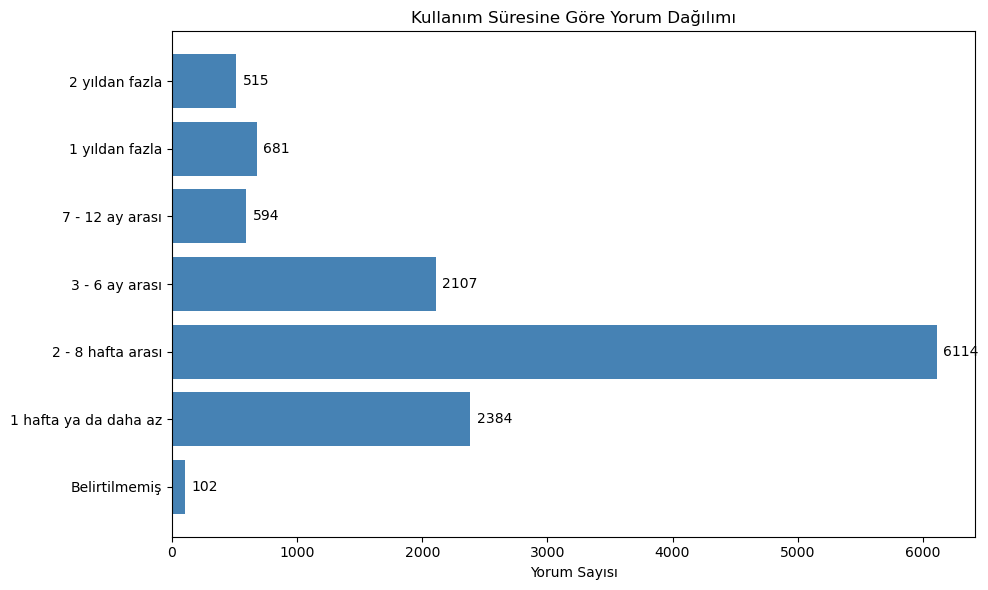

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

etiketler = {
    0: "Belirtilmemiş",
    1: "1 hafta ya da daha az",
    2: "2 - 8 hafta arası",
    3: "3 - 6 ay arası",
    4: "7 - 12 ay arası",
    5: "1 yıldan fazla",
    6: "2 yıldan fazla"
}

counts = df["KULLANIM_SURESI_KOD"].value_counts().sort_index()
labels = [etiketler[k] for k in counts.index]

plt.figure(figsize=(10, 6))
bars = plt.barh(labels, counts.values, color="steelblue")

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=10)

plt.xlabel("Yorum Sayısı")
plt.title("Kullanım Süresine Göre Yorum Dağılımı")
plt.tight_layout()
plt.savefig("kullanim_suresi_dagilim.png", dpi=150)
plt.show()


# SPOR MARKA


In [36]:
# Kaç benzersiz marka ve spor dalı var?
print(f"Marka sayısı: {df['MARKA'].nunique()}")
print(f"Spor dalı sayısı: {df['SPOR_DALI'].nunique()}")
print(df["SPOR_DALI"].value_counts())


Marka sayısı: 18
Spor dalı sayısı: 16
SPOR_DALI
outdoor_sporlar       5017
kosu                  1910
paten                 1162
futbol                 956
avcilik                949
fitness_kardiyo        600
basketbol              591
yuruyus_ayakkabisi     520
tenis                  489
voleybol               109
at_binicilik            60
tirmanis_dagcilik       43
snowboard               42
masa_tenisi             20
bale                    18
jimnastik               11
Name: count, dtype: int64


In [37]:
print("=== SPOR_DALI ===")
print(df["SPOR_DALI"].value_counts().sort_index())
print(f"\nBenzersiz spor dalı sayısı: {df['SPOR_DALI'].nunique()}")

print("\n=== MARKA ===")
print(df["MARKA"].value_counts().sort_index())
print(f"\nBenzersiz marka sayısı: {df['MARKA'].nunique()}")



=== SPOR_DALI ===
SPOR_DALI
at_binicilik            60
avcilik                949
bale                    18
basketbol              591
fitness_kardiyo        600
futbol                 956
jimnastik               11
kosu                  1910
masa_tenisi             20
outdoor_sporlar       5017
paten                 1162
snowboard               42
tenis                  489
tirmanis_dagcilik       43
voleybol               109
yuruyus_ayakkabisi     520
Name: count, dtype: int64

Benzersiz spor dalı sayısı: 16

=== MARKA ===
MARKA
Allsix          96
Artengo        289
Asics           22
Decathlon     1304
Domyos         108
Dreamscape      20
Fouganza        60
Kalenji        714
Kiprun        1120
Kipsta         960
Oxelo         1162
Pongori         20
Quechua       5008
Rossignol        5
Simond          52
Solognac       949
Tarmak         591
Wedze           17
Name: count, dtype: int64

Benzersiz marka sayısı: 18


In [38]:
spor_dali_map = {
    "at_binicilik"       : 1,
    "avcilik"            : 2,
    "bale"               : 3,
    "basketbol"          : 4,
    "fitness_kardiyo"    : 5,
    "futbol"             : 6,
    "jimnastik"          : 7,
    "kosu"               : 8,
    "masa_tenisi"        : 9,
    "outdoor_sporlar"    : 10,
    "paten"              : 11,
    "snowboard"          : 12,
    "tenis"              : 13,
    "tirmanis_dagcilik"  : 14,
    "voleybol"           : 15,
    "yuruyus_ayakkabisi" : 16
}

marka_map = {
    "Allsix"      : 1,
    "Artengo"     : 2,
    "Asics"       : 3,
    "Decathlon"   : 4,
    "Domyos"      : 5,
    "Dreamscape"  : 6,
    "Fouganza"    : 7,
    "Kalenji"     : 8,
    "Kiprun"      : 9,
    "Kipsta"      : 10,
    "Oxelo"       : 11,
    "Pongori"     : 12,
    "Quechua"     : 13,
    "Rossignol"   : 14,
    "Simond"      : 15,
    "Solognac"    : 16,
    "Tarmak"      : 17,
    "Wedze"       : 18
}

df["SPOR_DALI_KOD"] = df["SPOR_DALI"].str.strip().map(spor_dali_map)
df["MARKA_KOD"] = df["MARKA"].str.strip().map(marka_map)

print(f"SPOR_DALI eşleşmeyen: {df['SPOR_DALI_KOD'].isna().sum()}")
print(f"MARKA eşleşmeyen: {df['MARKA_KOD'].isna().sum()}")

# Kontrol tablosu
print(df[["SPOR_DALI", "SPOR_DALI_KOD", "MARKA", "MARKA_KOD"]].drop_duplicates().sort_values("SPOR_DALI_KOD"))


SPOR_DALI eşleşmeyen: 0
MARKA eşleşmeyen: 0
                SPOR_DALI  SPOR_DALI_KOD       MARKA  MARKA_KOD
0            at_binicilik              1    Fouganza          7
60                avcilik              2    Solognac         16
1009                 bale              3      Domyos          5
1027            basketbol              4      Tarmak         17
1618      fitness_kardiyo              5   Decathlon          4
2139      fitness_kardiyo              5      Domyos          5
2218               futbol              6      Kipsta         10
3174            jimnastik              7      Domyos          5
3185                 kosu              8   Decathlon          4
3259                 kosu              8       Asics          3
3261                 kosu              8     Kalenji          8
3975                 kosu              8      Kiprun          9
5095          masa_tenisi              9     Pongori         12
10123     outdoor_sporlar             10      Simond        

In [39]:
# Orijinal kategorik sütunları düşür, kodlu hallerini tut
df_temiz = df.drop(columns=["SPOR_DALI", "MARKA", "YORUM_KULLANIM_SURESI"])

df_temiz = df[[
    "SIRA_NO",
    "URUN_NO",
    "LINK_AD",
    "SPOR_DALI_KOD",
    "MARKA_KOD",
    "FIYAT",
    "TUM_YORUM",
    "TUM_YILDIZ",
    "YORUM_YILDIZ",
    "KULLANIM_SURESI_KOD",
    "YORUM",
    "YORUMUN_POLARITESI"
]]

print(df_temiz.columns.tolist())
print(f"Satır sayısı: {len(df_temiz)}")
df_temiz.head()



['SIRA_NO', 'URUN_NO', 'LINK_AD', 'SPOR_DALI_KOD', 'MARKA_KOD', 'FIYAT', 'TUM_YORUM', 'TUM_YILDIZ', 'YORUM_YILDIZ', 'KULLANIM_SURESI_KOD', 'YORUM', 'YORUMUN_POLARITESI']
Satır sayısı: 12497


,SIRA_NO,URUN_NO,LINK_AD,SPOR_DALI_KOD,MARKA_KOD,FIYAT,TUM_YORUM,TUM_YILDIZ,YORUM_YILDIZ,KULLANIM_SURESI_KOD,YORUM,YORUMUN_POLARITESI
0,1,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,2,"Görünüm ve tasarım başarısıyla, rahatlık ve şı...",NaN
1,2,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,1,Ürün elime Aras kargo sebebiyle ulaşmadı. Karg...,NaN
2,3,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,1,Ürün gerçekten fiyatına göre iyi. Eğer ayağını...,NaN
3,4,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,2,Ürün çok kaliteli tam kalıp işimi gördü baya a...,NaN
4,5,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,2,Çizme çok güzel binicilik için tam olması gere...,NaN


In [40]:
df_temiz.to_excel("veri_temiz.xlsx", index=False)
print("Kaydedildi!")


Kaydedildi!


In [41]:
import pandas as pd
df = pd.read_excel("veri_temiz.xlsx")
df.head()


,SIRA_NO,URUN_NO,LINK_AD,SPOR_DALI_KOD,MARKA_KOD,FIYAT,TUM_YORUM,TUM_YILDIZ,YORUM_YILDIZ,KULLANIM_SURESI_KOD,YORUM,YORUMUN_POLARITESI
0,1,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,2,"Görünüm ve tasarım başarısıyla, rahatlık ve şı...",NaN
1,2,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,1,Ürün elime Aras kargo sebebiyle ulaşmadı. Karg...,NaN
2,3,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,1,Ürün gerçekten fiyatına göre iyi. Eğer ayağını...,NaN
3,4,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,2,Ürün çok kaliteli tam kalıp işimi gördü baya a...,NaN
4,5,1,https://www.decathlon.com.tr/r/yetiskin-binici...,1,7,1190,12,4.7,5,2,Çizme çok güzel binicilik için tam olması gere...,NaN


# VERİ ON ISLEME ( YORUM )

- Noktalama silme - BERT'in attention mekanizması noktalama işaretlerini cümle sınırı ve vurgu işareti olarak kullanır. "Güzel, ama pahalı." ile "Güzel ama pahalı" modelce farklı işlenir.

- Küçük harfe çevirme - savasy/bert-base-turkish-sentiment-cased modeli cased olarak eğitilmiştir, yani "Kötü" ile "kötü" arasındaki farkı öğrenmiştir. Küçük harfe çevirmek modeli kendi eğitim dağılımından uzaklaştırır ve performansı düşürür.

- Stopword silme & Stemming/Lemmatization - BERT token'ları bağlamsal olarak işler; "bu ürünü almadım" cümlesindeki "bu", "ürünü", "almadım" kelimeleri birbirinin anlamını etkiler. Stopword silmek bağlamı bozar, stemming ise koşuyorum → koş dönüşümüyle subword tokenization'ı mahveder.

In [47]:
import re

# 1. Boş yorumları düşür
df = df[df["YORUM"].notna()]
df = df[df["YORUM"].str.strip() != ""]

# 2. Baştaki/sondaki boşlukları temizle
df["YORUM"] = df["YORUM"].str.strip()

# 3. Fazla boşluk, tab, newline temizle
df["YORUM"] = df["YORUM"].str.replace(r'\s+', ' ', regex=True)

# 4. URL temizle
df["YORUM"] = df["YORUM"].str.replace(r'http\S+|www\S+', '', regex=True)

# 5. Mention temizle (@kullanici)
df["YORUM"] = df["YORUM"].str.replace(r'@\w+', '', regex=True)

# 6. HTML entity temizle (&amp; &lt; vb.)
import html
df["YORUM"] = df["YORUM"].apply(html.unescape)

# 7. Temizleme sonrası boş kalan satırları düşür
df = df[df["YORUM"].str.strip() != ""]
df = df.reset_index(drop=True)

print(f"Temizleme sonrası satır sayısı: {len(df)}")
df["YORUM"].head(10)


Temizleme sonrası satır sayısı: 12497


0    Görünüm ve tasarım başarısıyla, rahatlık ve şı...
1    Ürün elime Aras kargo sebebiyle ulaşmadı. Karg...
2    Ürün gerçekten fiyatına göre iyi. Eğer ayağını...
3    Ürün çok kaliteli tam kalıp işimi gördü baya a...
4    Çizme çok güzel binicilik için tam olması gere...
5    Ürün çok güzel sağlam ve duruşu şık zira benim...
6    Üzerinde çizikler vardı, kullanmam gerektiği i...
7                             Baya sağlam ve dayanıklı
8                                 Gayet güzel bir ürün
9    uzun süre giyilecekse uygun degil terletiyor a...
Name: YORUM, dtype: object

In [48]:
# Temizleme öncesi baş/son boşluklu yorum var mıydı?
bosluklu = df["YORUM"].str.startswith(' ') | df["YORUM"].str.endswith(' ')
print(f"Baş/son boşluklu yorum sayısı: {bosluklu.sum()}")

# Varsa örnek göster
if bosluklu.sum() > 0:
    print(df[bosluklu]["YORUM"].head(5).tolist())
else:
    print("✅ Hiç baş/son boşluk yok, temizlik başarılı!")


Baş/son boşluklu yorum sayısı: 0
✅ Hiç baş/son boşluk yok, temizlik başarılı!


### Yapılmaması Gerekenler

❌ Noktalama silme — BERT noktalamayı anlam için kullanır

❌ Küçük harfe çevirme — model cased (büyük/küçük harf duyarlı), dönüştürme performansı düşürür

❌ Stopword silme — BERT bağlamsal, stopword'ler anlam taşır

❌ Stemming/lemmatization — kesinlikle yapma

### Yapılması Gerekenler

Boşluk temizleme — baştaki/sondaki boşlukları kaldır (str.strip())

NaN / boş yorumları filtrele — boş satırları modele gönderme

In [52]:

import re

emoji_pattern = re.compile(
    "[\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F9FF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)

# Tamamen emojiden oluşan yorumları bul
sadece_emoji = df[df["YORUM"].apply(
    lambda x: bool(re.fullmatch(r'[\s\U0001F000-\U0001FFFF\u2600-\u27BF]+', x.strip()))
)]

print(f"Tamamen emoji olan yorum sayısı: {len(sadece_emoji)}")
print(sadece_emoji["YORUM"].head(10).tolist())


Tamamen emoji olan yorum sayısı: 34
['👏👏👏👍', '🏆', '👍', '👍🤝👏👏🤝👍🤝🤝👍👍👏👏', '👍', '👍👍👍👍👍👍', '👍', '👍', '👍', '👍👍']


In [53]:
# 34 satırı düşür
df = df[~df["YORUM"].apply(
    lambda x: bool(re.fullmatch(r'[\s\U0001F000-\U0001FFFF\u2600-\u27BF]+', x.strip()))
)]

df = df.reset_index(drop=True)
print(f"Kalan satır sayısı: {len(df)}")


Kalan satır sayısı: 12463


Yalnızca emoji içeren ve herhangi bir metin barındırmayan 34 yorum, model için anlamlı girdi oluşturmadığından veri setinden çıkarılmıştır.

In [55]:
# Tüm temizleme işlemleri bitti, son hali kaydet
df.to_excel("3-veri_temiz_son.xlsx", index=False)
print(f"Kaydedildi! Toplam satır: {len(df)}")
print(f"Sütunlar: {df.columns.tolist()}")


Kaydedildi! Toplam satır: 12463
Sütunlar: ['SIRA_NO', 'URUN_NO', 'LINK_AD', 'SPOR_DALI_KOD', 'MARKA_KOD', 'FIYAT', 'TUM_YORUM', 'TUM_YILDIZ', 'YORUM_YILDIZ', 'KULLANIM_SURESI_KOD', 'YORUM', 'YORUMUN_POLARITESI']
